<a href="https://colab.research.google.com/github/Kimia998/Forecasting-of-3-Month-Gold-Returns/blob/main/Gold_Price_Forecasting_github.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Gold Price Forecasting: Predicting 3-Month Gold Returns with Machine Learning

## **Project Overview**
This project analyzes whether macroeconomic and geopolitical factors can help predict future 3-month gold returns.

The goal is not to perfectly predict gold prices, but to evaluate which indicators provide useful predictive signals.

## 1. Import Libraries

The required Python libraries are loaded for data handling, machine learning, model evaluation and visualization.

In [60]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from itertools import product

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

from autogluon.tabular import TabularPredictor, TabularDataset

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor


## Optional Setup

In [43]:
!pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longe

## 2. Load and Prepare Data

The dataset combines several time-series variables:

, Gold prices  
, Crude oil prices  
, USD index  
, CPI / inflation  
, VIX  
, real yields  
, geopolitical and Middle East risk indicators  

The data is cleaned, date columns are standardized, numeric values are converted, and all datasets are restricted to a common time period starting from 2006.
All datasets are aligned by date and transformed into features suitable for machine learning.

This covers:

  1. LOAD FILES
  2. RENAME COLUMNS
  3. CONVERT DATES
  4. CLEAN NUMERIC COLUMNS
  5. FILTER FROM 2006 ONWARD
  6. SORT ASCENDING AND DROP DUPLICATES
  7. CHECK DATE RANGES
  8. COMMON PREDICTOR END DATE


In [61]:
# 1. LOAD FILES
# =========================================================
gold = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Gold prices _ daily.csv")
oil = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Crude Oil Prices Brent - Europe.csv")
usd = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Nominal Broad U.S. Dollar Index.csv")
inflation = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Consumer Price Index.csv")
vix = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/VIXCLS.csv")
real_yield = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Market Yield on U.S. Treasury Securities_inflation.csv")

# =========================================================
# 2. RENAME COLUMNS
# Gold file has: Date, Open, High, Low, Close
# We use Close as gold_price
# =========================================================
gold = gold.rename(columns={
    "Date": "date",
    "Open": "gold_open",
    "High": "gold_high",
    "Low": "gold_low",
    "Close": "gold_price"
})

oil = oil.rename(columns={
    "observation_date": "date",
    "DCOILBRENTEU": "oil_price"
})

usd = usd.rename(columns={
    "observation_date": "date",
    "DTWEXBGS": "usd_index"
})

inflation = inflation.rename(columns={
    "observation_date": "date",
    "CPIAUCSL": "cpi"
})


vix = vix.rename(columns={
    "observation_date": "date",
    "VIXCLS": "vix"
})

real_yield = real_yield.rename(columns={
    "observation_date": "date",
    "DFII10": "real_yield"
})

# =========================================================
# 3. CONVERT DATES
# =========================================================
gold["date"] = pd.to_datetime(gold["date"], errors="coerce")
oil["date"] = pd.to_datetime(oil["date"], errors="coerce")
usd["date"] = pd.to_datetime(usd["date"], errors="coerce")
inflation["date"] = pd.to_datetime(inflation["date"], errors="coerce")
vix["date"] = pd.to_datetime(vix["date"], errors="coerce")
real_yield["date"] = pd.to_datetime(real_yield["date"], errors="coerce")

# =========================================================
# 4. CLEAN NUMERIC COLUMNS
# Handles commas, spaces, and FRED missing values like "."
# =========================================================
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace(",", "", regex=False)
              .str.replace(" ", "", regex=False)
              .replace(".", np.nan),
        errors="coerce"
    )

gold["gold_open"] = clean_numeric(gold["gold_open"])
gold["gold_high"] = clean_numeric(gold["gold_high"])
gold["gold_low"] = clean_numeric(gold["gold_low"])
gold["gold_price"] = clean_numeric(gold["gold_price"])

oil["oil_price"] = clean_numeric(oil["oil_price"])
usd["usd_index"] = clean_numeric(usd["usd_index"])
inflation["cpi"] = clean_numeric(inflation["cpi"])
vix["vix"] = clean_numeric(vix["vix"])
real_yield["real_yield"] = clean_numeric(real_yield["real_yield"])

# =========================================================
# 5. FILTER FROM 2006 ONWARD
# =========================================================
gold = gold[gold["date"] >= "2006-01-01"].copy()
oil = oil[oil["date"] >= "2006-01-01"].copy()
usd = usd[usd["date"] >= "2006-01-01"].copy()
inflation = inflation[inflation["date"] >= "2006-01-01"].copy()
vix = vix[vix["date"] >= "2006-01-01"].copy()
real_yield = real_yield[real_yield["date"] >= "2006-01-01"].copy()

# =========================================================
# 6. SORT ASCENDING AND DROP DUPLICATES
# =========================================================
gold = gold.sort_values("date").drop_duplicates("date")
oil = oil.sort_values("date").drop_duplicates("date")
usd = usd.sort_values("date").drop_duplicates("date")
inflation = inflation.sort_values("date").drop_duplicates("date")
vix = vix.sort_values("date").drop_duplicates("date")
real_yield = real_yield.sort_values("date").drop_duplicates("date")

# =========================================================
# 7. CHECK DATE RANGES
# =========================================================
print("Gold:", gold["date"].min(), "to", gold["date"].max())
print("Oil:", oil["date"].min(), "to", oil["date"].max())
print("USD:", usd["date"].min(), "to", usd["date"].max())
print("CPI:", inflation["date"].min(), "to", inflation["date"].max())
print("VIX:", vix["date"].min(), "to", vix["date"].max())
print("Real Yield:", real_yield["date"].min(), "to", real_yield["date"].max())

# =========================================================
# 8. COMMON PREDICTOR END DATE
# Gold may go further, keep it for future target creation
# Predictors define the last usable input date
# =========================================================
common_predictor_end = min(
    oil["date"].max(),
    usd["date"].max(),
    inflation["date"].max(),
    vix["date"].max(),
    real_yield["date"].max()
)

print("Common predictor end date:", common_predictor_end)

oil = oil[oil["date"] <= common_predictor_end].copy()
usd = usd[usd["date"] <= common_predictor_end].copy()
inflation = inflation[inflation["date"] <= common_predictor_end].copy()
vix = vix[vix["date"] <= common_predictor_end].copy()
real_yield = real_yield[real_yield["date"] <= common_predictor_end].copy()


Gold: 2006-03-01 00:00:00 to 2026-04-10 00:00:00
Oil: 2006-01-03 00:00:00 to 2026-03-31 00:00:00
USD: 2006-01-02 00:00:00 to 2026-03-31 00:00:00
CPI: 2006-01-01 00:00:00 to 2026-02-01 00:00:00
VIX: 2006-01-03 00:00:00 to 2026-04-13 00:00:00
Real Yield: 2006-01-03 00:00:00 to 2026-04-09 00:00:00
Common predictor end date: 2026-02-01 00:00:00


## 3. Merge Time-Series Data

Gold trading dates are used as the base calendar.  
Macroeconomic predictors are merged using backward-looking date alignment, so only information available up to each date is used.

Missing predictor values are forward-filled to carry forward the last known value and avoid future data leakage.

This covers:
  9. MERGE DAILY DATA IN PANDAS
  10. FORWARD FILL PREDICTOR GAPS

In [62]:

# 9. MERGE DAILY DATA IN PANDAS
# Base calendar = gold trading dates
# direction='backward' uses only information known up to that day
# =========================================================
df_merged = gold[["date", "gold_open", "gold_high", "gold_low", "gold_price"]].copy()

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    oil[["date", "oil_price"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    usd[["date", "usd_index"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    inflation[["date", "cpi"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    vix[["date", "vix"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    real_yield[["date", "real_yield"]].sort_values("date"),
    on="date",
    direction="backward"
)


# =========================================================
# 10. FORWARD FILL PREDICTOR GAPS
# This keeps the last known past value, no future leakage
# =========================================================
df_merged["oil_price"] = df_merged["oil_price"].ffill()
df_merged["usd_index"] = df_merged["usd_index"].ffill()
df_merged["cpi"] = df_merged["cpi"].ffill()
df_merged["vix"] = df_merged["vix"].ffill()
df_merged["real_yield"] = df_merged["real_yield"].ffill()

print("\nMissing values after forward fill:")
print(df_merged[["oil_price", "usd_index", "cpi", "real_yield", "vix"]].isna().sum())

print("\nMissing values after merge:")
print(df_merged.isna().sum())


Missing values after forward fill:
oil_price     0
usd_index     0
cpi           0
real_yield    0
vix           0
dtype: int64

Missing values after merge:
date          0
gold_open     0
gold_high     0
gold_low      0
gold_price    0
oil_price     0
usd_index     0
cpi           0
vix           0
real_yield    0
dtype: int64


## 4. Geopolitical Risk Variables

Two manually defined risk indicators are added:

, `geopolitical_risk_level` for broader geopolitical tension  
, `middle_east_level` for Middle East related risk periods  

The variables are encoded ordinally to represent different intensity levels.


This covers:
  11. xxxxxxxxxxxxxxxxxxxx

In [63]:
# 11. GEOPOLITICAL VARIABLES
# =========================================================
df_merged["geopolitical_risk_level"] = 0
df_merged["middle_east_level"] = 0

df_merged.loc[
    (df_merged["date"] >= "2014-03-01") & (df_merged["date"] < "2022-02-01"),
    "geopolitical_risk_level"
] = 1

df_merged.loc[
    df_merged["date"] >= "2022-02-01",
    "geopolitical_risk_level"
] = 2

df_merged.loc[
    (df_merged["date"] >= "2011-01-01") & (df_merged["date"] <= "2012-12-31"),
    "middle_east_level"
] = 1

df_merged.loc[
    (df_merged["date"] >= "2023-10-01") & (df_merged["date"] < "2024-04-01"),
    "middle_east_level"
] = 1

df_merged.loc[
    df_merged["date"] >= "2024-04-01",
    "middle_east_level"
] = 2


## 5. Feature Engineering

Several predictive features are created from the raw time-series data.

These include:

, gold momentum over different time windows  
, moving averages and distance from trend  
, gold volatility  
, intraday price range features  
, macroeconomic changes  
, macro moving averages  

The feature windows use trading-day approximations, where 21 trading days represent about one month and 63 trading days about three months.

This covers:
  12. DAILY FEATURE ENGINEERING

In [64]:
# 12. BUILD df_model
# =========================================================
df_model = df_merged.sort_values("date").copy()

# Gold features
df_model["gold_return_1d"] = df_model["gold_price"].pct_change(fill_method=None)

df_model["gold_mom_21d"] = df_model["gold_price"].pct_change(21, fill_method=None)
df_model["gold_mom_63d"] = df_model["gold_price"].pct_change(63, fill_method=None)
df_model["gold_mom_126d"] = df_model["gold_price"].pct_change(126, fill_method=None)

df_model["gold_ma21"] = df_model["gold_price"].rolling(21).mean()
df_model["gold_ma63"] = df_model["gold_price"].rolling(63).mean()

df_model["gold_vs_ma21"] = df_model["gold_price"] / df_model["gold_ma21"] - 1
df_model["gold_vs_ma63"] = df_model["gold_price"] / df_model["gold_ma63"] - 1

df_model["gold_vol_21d"] = df_model["gold_return_1d"].rolling(21).std()
df_model["gold_vol_63d"] = df_model["gold_return_1d"].rolling(63).std()

df_model["gold_intraday_return"] = (df_model["gold_price"] / df_model["gold_open"]) - 1
df_model["gold_range_pct"] = (df_model["gold_high"] - df_model["gold_low"]) / df_model["gold_price"]

# Existing macro features
df_model["oil_change_21d"] = df_model["oil_price"].pct_change(21, fill_method=None)
df_model["usd_change_21d"] = df_model["usd_index"].pct_change(21, fill_method=None)
df_model["cpi_change_21d"] = df_model["cpi"].pct_change(21, fill_method=None)

df_model["oil_change_63d"] = df_model["oil_price"].pct_change(63, fill_method=None)
df_model["usd_change_63d"] = df_model["usd_index"].pct_change(63, fill_method=None)
df_model["cpi_change_63d"] = df_model["cpi"].pct_change(63, fill_method=None)

df_model["oil_ma21"] = df_model["oil_price"].rolling(21).mean()
df_model["usd_ma21"] = df_model["usd_index"].rolling(21).mean()
df_model["cpi_ma21"] = df_model["cpi"].rolling(21).mean()

# Real yield features , use differences, not pct_change
df_model["real_yield_diff_21d"] = df_model["real_yield"] - df_model["real_yield"].shift(21)
df_model["real_yield_diff_63d"] = df_model["real_yield"] - df_model["real_yield"].shift(63)
df_model["real_yield_ma21"] = df_model["real_yield"].rolling(21).mean()

# VIX features
df_model["vix_change_21d"] = df_model["vix"].pct_change(21, fill_method=None)
df_model["vix_change_63d"] = df_model["vix"].pct_change(63, fill_method=None)
df_model["vix_ma21"] = df_model["vix"].rolling(21).mean()

## 6. Target Variable: 3-Month Forward Gold Return

The target variable is the future 3-month gold return.

For each observation date, the model predicts how much the gold price changes over the following three months.

This covers:
  13. CREATE 3-MONTH FUTURE TARGET

In [65]:
# 13. TARGET
# =========================================================
df_model["expected_future_3m"] = df_model["date"] + pd.DateOffset(months=3)

future_prices = df_model[["date", "gold_price"]].rename(columns={
    "date": "future_date_actual",
    "gold_price": "future_gold_price_3m"
})

df_model = pd.merge_asof(
    df_model.sort_values("expected_future_3m"),
    future_prices.sort_values("future_date_actual"),
    left_on="expected_future_3m",
    right_on="future_date_actual",
    direction="forward",
    tolerance=pd.Timedelta("10D")
)

df_model = df_model.sort_values("date").copy()

df_model["target_return_3m"] = (
    df_model["future_gold_price_3m"] / df_model["gold_price"] - 1
)

df_model = df_model[df_model["date"] <= common_predictor_end].copy()

## 7. Feature Set Comparison: Real Yield vs. Real Yield + VIX

To evaluate whether volatility information improves the model, two feature sets are compared:

, Real-yield feature set  
, Combined feature set with real-yield and VIX features  

Both models are trained and tested on the same rows to ensure a fair comparison.

It covers:
  14. FEATURE SETS

In [66]:
# 14. FEATURE SETS
# =========================================================
feature_cols_real_yield_partial = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "real_yield_diff_21d",
    "real_yield_diff_63d",
    "real_yield_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

feature_cols_combined_partial = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "real_yield_diff_21d",
    "real_yield_diff_63d",
    "real_yield_ma21",
    "vix_change_21d",
    "vix_change_63d",
    "vix_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

The combined model with real-yield and VIX features achieved the best performance and was selected as the final feature set.

## 8. Fair Comparison Dataset

Both feature sets are compared on the same rows to ensure a fair evaluation.  
Rows with missing or infinite values are removed, and the data is split chronologically into training and test sets.

In [67]:
# 15. FAIR COMPARISON ON SAME ROWS
# =========================================================
all_features_for_compare = sorted(
    set(feature_cols_real_yield_partial + feature_cols_combined_partial)
)

df_compare = df_model.copy()
df_compare = df_compare.replace([np.inf, -np.inf], np.nan)
df_compare = df_compare.dropna(
    subset=all_features_for_compare + ["target_return_3m"]
).copy()

print("Rows used for comparison:", len(df_compare))

X_real_yield = df_compare[feature_cols_real_yield_partial]
X_combined = df_compare[feature_cols_combined_partial]
y = df_compare["target_return_3m"]

split_index = int(len(df_compare) * 0.8)

X_real_yield_train = X_real_yield.iloc[:split_index]
X_real_yield_test = X_real_yield.iloc[split_index:]

X_combined_train = X_combined.iloc[:split_index]
X_combined_test = X_combined.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Shapes:")
print("X_real_yield_train:", X_real_yield_train.shape, "X_real_yield_test:", X_real_yield_test.shape)
print("X_combined_train:", X_combined_train.shape, "X_combined_test:", X_combined_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


Rows used for comparison: 4999
Shapes:
X_real_yield_train: (3999, 22) X_real_yield_test: (1000, 22)
X_combined_train: (3999, 25) X_combined_test: (1000, 25)
y_train: (3999,) y_test: (1000,)


## 9. Model Comparison

Extra Trees models are trained on both feature sets and compared against a naive baseline.

The baseline predicts the average training return and is used as a minimum benchmark.

It covers:
  HELPERS
  COMPARE

In [68]:
# =========================================================
# 16. HELPERS
# =========================================================
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2:   {r2:.6f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

def fit_extra_trees(Xtr, ytr, Xte):
    model = ExtraTreesRegressor(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    return model, preds

# =========================================================
# 17. COMPARE
# =========================================================
results = []

baseline_pred = np.repeat(y_train.mean(), len(y_test))
results.append(evaluate_model("Naive Baseline", y_test, baseline_pred))

best_model, y_pred_best = fit_extra_trees(X_real_yield_train, y_train, X_real_yield_test)
results.append(evaluate_model("Extra Trees , Current Best (Real Yield Partial)", y_test, y_pred_best))

combined_model, y_pred_combined = fit_extra_trees(X_combined_train, y_train, X_combined_test)
results.append(evaluate_model("Extra Trees , Combined (Real Yield + VIX)", y_test, y_pred_combined))

results_df = pd.DataFrame(results).sort_values("RMSE")
print("\nComparison Table")
print(results_df)


Naive Baseline
MAE:  0.076915
RMSE: 0.097606
R2:   -0.259770

Extra Trees , Current Best (Real Yield Partial)
MAE:  0.062269
RMSE: 0.078707
R2:   0.180851

Extra Trees , Combined (Real Yield + VIX)
MAE:  0.061413
RMSE: 0.076950
R2:   0.217016

Comparison Table
                                             Model       MAE      RMSE  \
2        Extra Trees , Combined (Real Yield + VIX)  0.061413  0.076950   
1  Extra Trees , Current Best (Real Yield Partial)  0.062269  0.078707   
0                                   Naive Baseline  0.076915  0.097606   

         R2  
2  0.217016  
1  0.180851  
0 -0.259770  


## 10. Feature Importance of the Final Model

The combined model is interpreted using feature importance to identify which variables contributed most to the prediction.

This step helps connect the model results with economic interpretation.

It covers:
  FEATURE IMPORTANCE OF COMBINED MODEL


Feature Importance , Combined Model
                    Feature  Importance
19          real_yield_ma21    0.180835
13                 oil_ma21    0.126014
14                 usd_ma21    0.116998
15                      cpi    0.084196
16                 cpi_ma21    0.078757
6              gold_vol_63d    0.055731
24        middle_east_level    0.048140
22                 vix_ma21    0.046010
2             gold_mom_126d    0.033036
12           cpi_change_63d    0.031040
1              gold_mom_63d    0.028955
4              gold_vs_ma63    0.025861
11           usd_change_63d    0.023797
9            cpi_change_21d    0.023645
23  geopolitical_risk_level    0.014849
5              gold_vol_21d    0.014369
10           oil_change_63d    0.011546
21           vix_change_63d    0.011333
0              gold_mom_21d    0.008848
18      real_yield_diff_63d    0.008172
3              gold_vs_ma21    0.007731
7            oil_change_21d    0.007452
17      real_yield_diff_21d    0.005608
8  

/tmp/ipykernel_20177/3807463888.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_combined, x="Importance", y="Feature", palette="viridis")


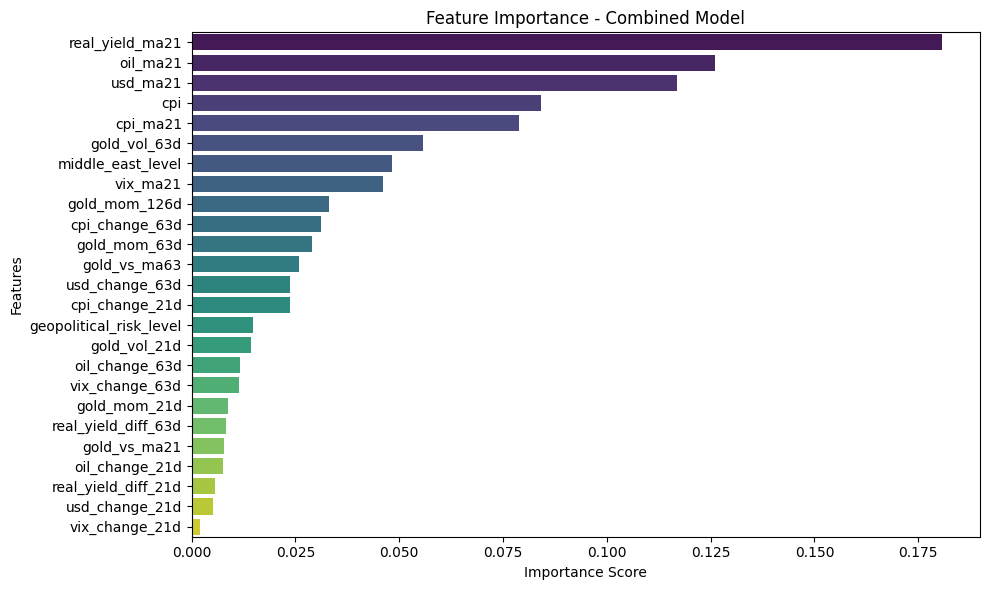

In [69]:
# 18. FEATURE IMPORTANCE OF COMBINED MODEL
# =========================================================
importance_combined = pd.DataFrame({
    "Feature": feature_cols_combined_partial,
    "Importance": combined_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance , Combined Model")
print(importance_combined)


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_combined, x="Importance", y="Feature", palette="viridis")

plt.title("Feature Importance - Combined Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## 11. Prediction Preview

The final table compares actual 3-month gold returns with predictions from both model versions on the test set.

It covers:
  PREDICTIONS PREVIEW

In [70]:
# 19. PREDICTIONS PREVIEW
# =========================================================
predictions_compare = pd.DataFrame({
    "date": df_compare.iloc[split_index:]["date"].values,
    "actual_target_return_3m": y_test.values,
    "pred_current_best": y_pred_best,
    "pred_combined": y_pred_combined
})

print("\nPredictions preview")
print(predictions_compare.head(10))


Predictions preview
        date  actual_target_return_3m  pred_current_best  pred_combined
0 2022-02-24                -0.019728           0.010601       0.012961
1 2022-02-25                -0.019825           0.007919       0.009147
2 2022-02-28                -0.028083           0.004248       0.007488
3 2022-03-01                -0.050757           0.002959       0.008143
4 2022-03-02                -0.031122           0.000880       0.005686
5 2022-03-03                -0.044174           0.000445       0.004333
6 2022-03-04                -0.063917          -0.005342      -0.000315
7 2022-03-07                -0.072726          -0.007754      -0.003096
8 2022-03-08                -0.096021          -0.017140      -0.009826
9 2022-03-09                -0.072303          -0.018160      -0.010456


## 12. Permutation Importance

Permutation importance is used as an additional interpretation method for the final combined model.

While the built-in Extra Trees feature importance shows how much a feature contributed during model construction, permutation importance tests how much model performance changes when each feature is randomly shuffled.

Positive values indicate that the feature improves predictive performance.  
Negative or very low values suggest that the feature adds little value or may introduce noise.


Permutation Importance , Combined Model
                    Feature  Importance
13                 oil_ma21    0.004864
24        middle_east_level    0.003733
19          real_yield_ma21    0.002404
14                 usd_ma21    0.001151
12           cpi_change_63d    0.000595
22                 vix_ma21    0.000195
8            usd_change_21d    0.000054
10           oil_change_63d    0.000047
21           vix_change_63d    0.000037
3              gold_vs_ma21    0.000034
20           vix_change_21d    0.000025
0              gold_mom_21d    0.000015
18      real_yield_diff_63d    0.000006
23  geopolitical_risk_level    0.000000
15                      cpi    0.000000
16                 cpi_ma21    0.000000
5              gold_vol_21d   -0.000021
17      real_yield_diff_21d   -0.000041
7            oil_change_21d   -0.000056
9            cpi_change_21d   -0.000056
6              gold_vol_63d   -0.000113
11           usd_change_63d   -0.000267
4              gold_vs_ma63   -0.000356

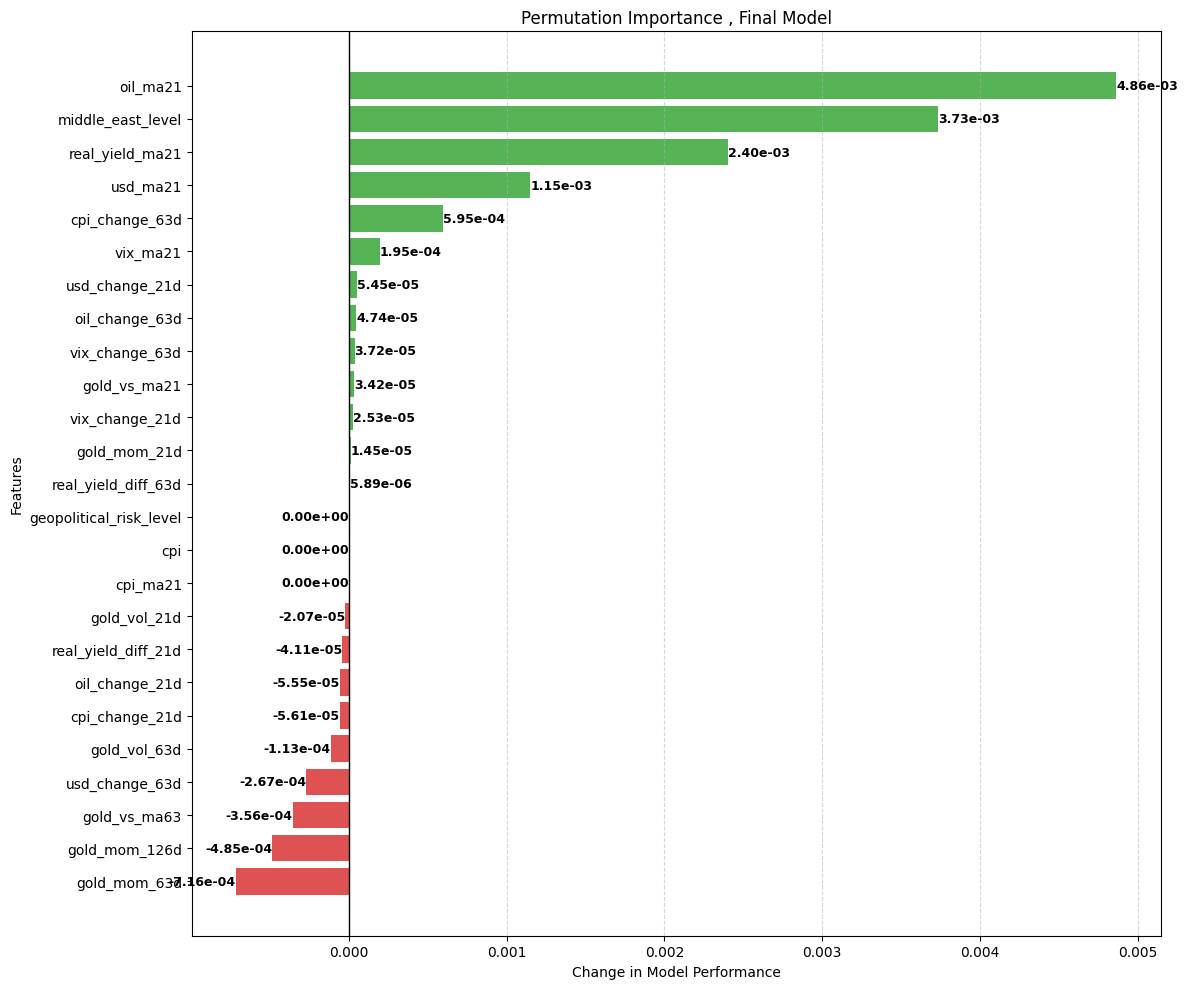

In [71]:
def fit_extra_trees(Xtr, ytr, Xte):
    model = ExtraTreesRegressor(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    return model, preds

split_index = int(len(df_compare) * 0.8)

X_combined_train = X_combined.iloc[:split_index]
X_combined_test = X_combined.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


combined_model, y_pred_combined = fit_extra_trees(X_combined_train, y_train, X_combined_test)

perm_importance = permutation_importance(
    combined_model,
    X_combined_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

perm_importance_df = pd.DataFrame({
    "Feature": X_combined_test.columns,
    "Importance": perm_importance.importances_mean
}).sort_values("Importance", ascending=False)

print("\nPermutation Importance , Combined Model")
print(perm_importance_df)

import matplotlib.pyplot as plt

# 1. Daten sortieren (Wichtigste oben)
perm_importance_df = perm_importance_df.sort_values("Importance", ascending=True)

# 2. Farbliste erstellen: Grün für positive Werte, Rot für negative
colors = ['#2ca02c' if x > 0 else '#d62728' for x in perm_importance_df["Importance"]]

# 3. Plot erstellen
plt.figure(figsize=(12, 10))
bars = plt.barh(perm_importance_df["Feature"], perm_importance_df["Importance"], color=colors, alpha=0.8)

# 4. Optische Verdeutlichung
plt.axvline(0, color='black', linestyle='-', linewidth=1)  # Deutliche Trennlinie bei 0
plt.title("Permutation Importance , Final Model")
plt.xlabel("Change in Model Performance")
plt.ylabel("Features")

# Gitter hinzufügen für bessere Lesbarkeit
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Werte-Labels an die Balken schreiben (optional, macht es sehr deutlich)
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.2e}',
             va='center', ha='left' if width > 0 else 'right',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 13. Correlation Heatmap

A correlation heatmap is used to explore linear relationships between the final features and the 3-month gold return target.

This step is only exploratory, because correlation does not capture non-linear effects or time-lagged relationships.

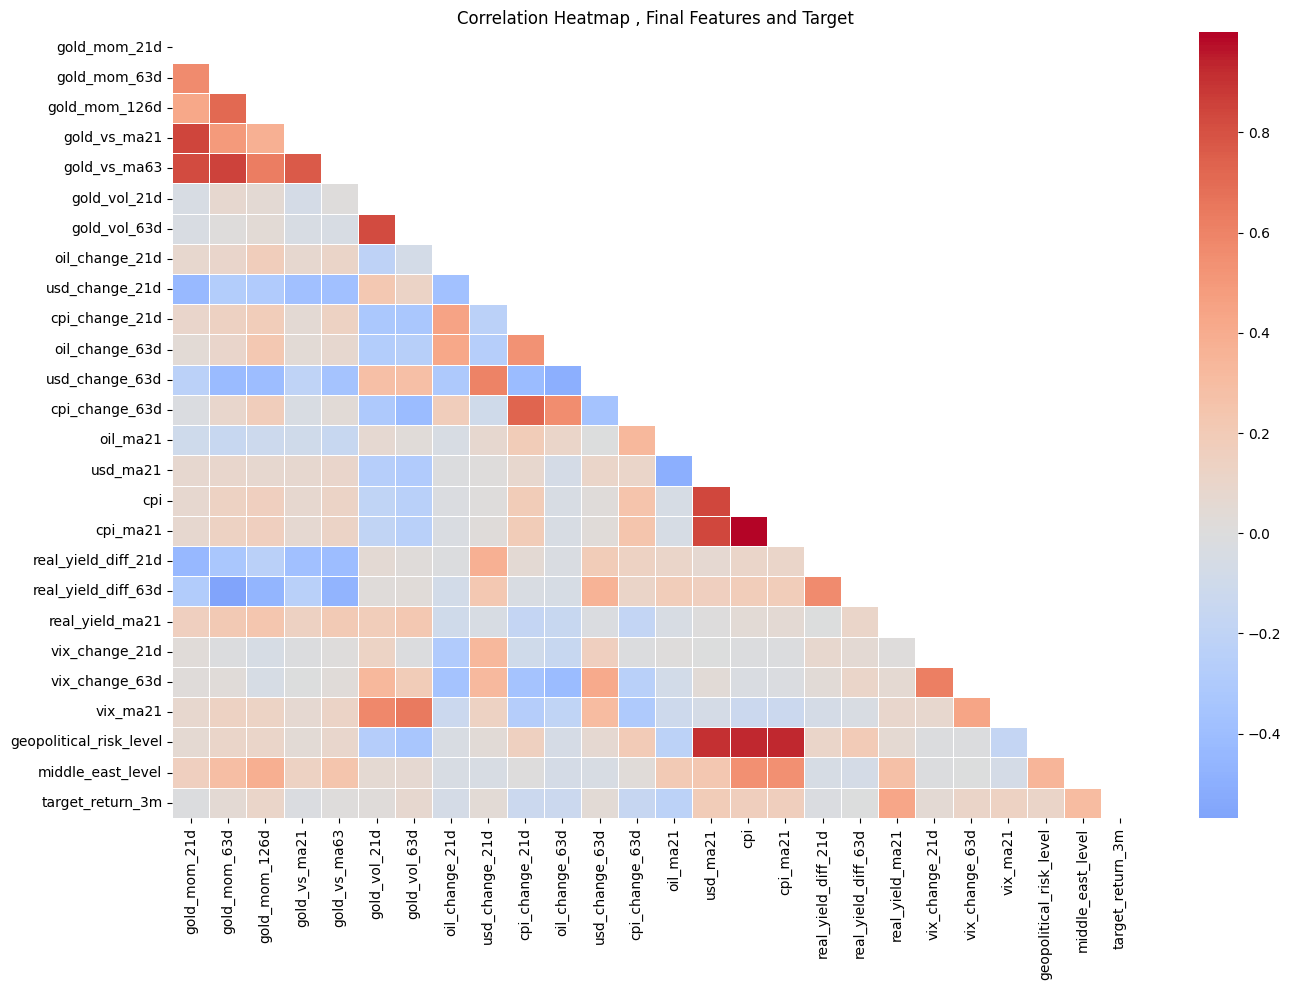

In [72]:
# =========================================================
# TRIANGULAR CORRELATION HEATMAP , FINAL FEATURES + TARGET
# =========================================================

corr_cols = feature_cols_combined_partial + ["target_return_3m"]
corr_matrix = df_compare[corr_cols].corr()

# Hide upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap , Final Features and Target")
plt.tight_layout()
plt.show()

## 14. AutoML Benchmark with AutoGluon

AutoGluon is used as an additional benchmark to compare the manually selected Extra Trees model with an automated machine learning approach.

The same final feature set is used: real-yield, VIX, macroeconomic, gold-market and geopolitical features.
The data is split chronologically to avoid data leakage, using the first 80% for training and the final 20% for testing.


In [44]:
feature_cols_final = feature_cols_combined_partial

## 15. AutoGluon Dataset Preparation

The dataset is cleaned and reduced to the final feature set, target variable and date column.  
The date column is kept only for later interpretation and removed before model training.

In [45]:
df_auto = df_model.copy()

df_auto = df_auto.replace([np.inf, -np.inf], np.nan)

df_auto = df_auto.dropna(
    subset=feature_cols_final + ["target_return_3m"]
).copy()

df_auto = df_auto[feature_cols_final + ["target_return_3m", "date"]]

## 16. Chronological Train-Test Split for AutoML

The data is split chronologically to avoid data leakage.  
The first 80% is used for training and the final 20% is used for testing.

In [46]:
split_index = int(len(df_auto) * 0.8)

train_data = df_auto.iloc[:split_index].drop(columns=["date"])
test_data = df_auto.iloc[split_index:].drop(columns=["date"])

test_dates = df_auto.iloc[split_index:]["date"].reset_index(drop=True)

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Train shape: (3999, 26)
Test shape: (1000, 26)


## 17. AutoGluon Model Training and Evaluation

AutoGluon trains and compares multiple regression models automatically.  
The evaluation metric is RMSE, which is also used in the manual model comparison.

In [51]:
predictor = TabularPredictor(
    label="target_return_3m",
    problem_type="regression",
    eval_metric="root_mean_squared_error"
).fit(
    train_data,
    time_limit=600,
    presets="best_quality"
)

performance = predictor.evaluate(test_data)

print("\nAutoGluon Test Performance")
print(performance)

leaderboard = predictor.leaderboard(test_data)
leaderboard

No path specified. Models will be saved in: "AutogluonModels/ag-20260428_144637"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.50 GB / 12.67 GB (82.9%)
Disk Space Avail:   75.42 GB / 107.72 GB (70.0%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable sta

(_ray_fit pid=58988) [1000]	valid_set's rmse: 0.0142844
(_ray_fit pid=58988) [2000]	valid_set's rmse: 0.0136129 [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(_ray_fit pid=58988) [4000]	valid_set's rmse: 0.013421 [repeated 4x across cluster]


(_ray_fit pid=58988) 	Ran out of time, early stopping on iteration 4054. Best iteration is:
(_ray_fit pid=58988) 	[4022]	valid_set's rmse: 0.0134196


(_ray_fit pid=59243) [1000]	valid_set's rmse: 0.0137511
(_ray_fit pid=59242) [1000]	valid_set's rmse: 0.0156997
(_ray_fit pid=59243) [3000]	valid_set's rmse: 0.0129182 [repeated 3x across cluster]
(_ray_fit pid=59243) [4000]	valid_set's rmse: 0.0128852 [repeated 2x across cluster]


(_ray_fit pid=59243) 	Ran out of time, early stopping on iteration 4365. Best iteration is: [repeated 2x across cluster]
(_ray_fit pid=59243) 	[4295]	valid_set's rmse: 0.0128807 [repeated 2x across cluster]


...

(_ray_fit pid=59461) 	Ran out of time, early stopping on iteration 4169. Best iteration is: [repeated 2x across cluster]
(_ray_fit pid=59461) 	[4154]	valid_set's rmse: 0.0131342 [repeated 2x across cluster]


(_ray_fit pid=59688) [1000]	valid_set's rmse: 0.0141383 [repeated 4x across cluster]
(_ray_fit pid=59688) [2000]	valid_set's rmse: 0.0133949 [repeated 2x across cluster]
(_ray_fit pid=59688) [4000]	valid_set's rmse: 0.0131171 [repeated 4x across cluster]


(_ray_fit pid=59688) 	Ran out of time, early stopping on iteration 4355. Best iteration is: [repeated 2x across cluster]
(_ray_fit pid=59688) 	[4273]	valid_set's rmse: 0.0131039 [repeated 2x across cluster]
(_dystack pid=58712) 	-0.0134	 = Validation score   (-root_mean_squared_error)
(_dystack pid=58712) 	119.03s	 = Training   runtime
(_dystack pid=58712) 	7.69s	 = Validation runtime
(_dystack pid=58712) Fitting model: WeightedEnsemble_L2 ... Training model for up to 127.73s of the -6.52s of remaining time.
(_dystack pid=58712) 	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.0/8.8 GB
(_dystack pid=58712) 	Ensemble Weights: {'LightGBMXT_BAG_L1': 1.0}
(_dystack pid=58712) 	-0.0134	 = Validation score   (-root_mean_squared_error)
(_dystack pid=58712) 	0.0s	 = Training   runtime
(_dystack pid=58712) 	0.0s	 = Validation runtime
(_dystack pid=58712) Fitting 106 L2 models, fit_strategy="sequential" ...
(_dystack pid=58712) Fitting model: WeightedEnsemble_L3 ... Training mod


AutoGluon Test Performance
{'root_mean_squared_error': np.float64(-0.08438208157090232), 'mean_squared_error': -0.007120335690238414, 'mean_absolute_error': -0.06711210361118236, 'r2': 0.05845765458227736, 'pearsonr': 0.26203653656239334, 'median_absolute_error': np.float64(-0.057754451220995984)}


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT_BAG_L2,-0.084327,-0.013577,root_mean_squared_error,29.910406,23.660203,353.942552,0.391157,0.416399,64.927254,2,True,4
1,WeightedEnsemble_L2,-0.084382,-0.012644,root_mean_squared_error,29.522131,23.244583,289.031956,0.002882,0.000778,0.016658,2,True,3
2,LightGBM_BAG_L2,-0.084685,-0.013289,root_mean_squared_error,29.606941,23.586281,350.114494,0.087692,0.342476,61.099196,2,True,5
3,WeightedEnsemble_L3,-0.085303,-0.012829,root_mean_squared_error,29.609960,23.587237,350.164643,0.003019,0.000956,0.050149,3,True,6
4,LightGBM_BAG_L1,-0.085527,-0.013869,root_mean_squared_error,4.283229,7.997118,113.500017,4.283229,7.997118,113.500017,1,True,2
5,LightGBMXT_BAG_L1,-0.085729,-0.012924,root_mean_squared_error,25.236020,15.246687,175.515281,25.236020,15.246687,175.515281,1,True,1


### Validation vs Test Performance

A noticeable gap between validation and test performance was observed.

This is mainly due to:
, the time-series nature of the data  
, potential overfitting during model selection  
, and changing market conditions over time  

Since AutoGluon uses random validation splits by default, validation results can appear overly optimistic compared to a true out-of-sample test set.

Therefore, the test set performance is considered the more reliable indicator of model quality.

### 18. AutoGluon Model Leaderboard

The leaderboard shows which automatically trained models performed best on the test set.

This helps compare whether AutoML can outperform the manually selected model.

In [55]:
leaderboard_clean = leaderboard[[
    "model",
    "score_test",
    "fit_time"
]].copy()

leaderboard_clean["RMSE"] = -leaderboard_clean["score_test"]

leaderboard_clean = leaderboard_clean.sort_values("RMSE")

leaderboard_clean

,model,score_test,fit_time,RMSE
0,LightGBMXT_BAG_L2,-0.084327,353.942552,0.084327
1,WeightedEnsemble_L2,-0.084382,289.031956,0.084382
2,LightGBM_BAG_L2,-0.084685,350.114494,0.084685
3,WeightedEnsemble_L3,-0.085303,350.164643,0.085303
4,LightGBM_BAG_L1,-0.085527,113.500017,0.085527
5,LightGBMXT_BAG_L1,-0.085729,175.515281,0.085729


## 19. Model Comparison: Manual vs AutoML

The AutoGluon model achieved a similar (or slightly better) RMSE compared to the manually tuned Extra Trees model.

This shows that:
, automated model selection can identify strong baseline models  
, but a well-designed feature engineering pipeline remains the key driver of performance  

Overall, both approaches confirm that macroeconomic and volatility features provide predictive signals for gold returns.

In [56]:
comparison_df = pd.DataFrame({
    "Model": [
        "Extra Trees (Manual)",
        "AutoGluon Best Model"
    ],
    "RMSE": [
        final_rmse,
        -leaderboard.iloc[0]["score_test"]
    ]
})

comparison_df

,Model,RMSE
0,Extra Trees (Manual),0.083051
1,AutoGluon Best Model,0.084327


## 20. AutoGluon Predictions

The final AutoGluon predictions are stored together with the actual target values and dates for interpretation.

In [54]:
y_pred_auto = predictor.predict(test_data)

autogluon_results_df = pd.DataFrame({
    "date": test_dates,
    "actual_target_return_3m": test_data["target_return_3m"].values,
    "autogluon_prediction": y_pred_auto.values
})

autogluon_results_df.head()

,date,actual_target_return_3m,autogluon_prediction
0,2022-02-24,-0.019728,-0.006070
1,2022-02-25,-0.019825,-0.005020
2,2022-02-28,-0.028083,-0.002808
3,2022-03-01,-0.050757,-0.002298
4,2022-03-02,-0.031122,-0.009762


## 21. Neural Network Benchmark

A neural network model is tested as an additional benchmark using the same final feature set as the selected tree-based model.

Because neural networks are sensitive to feature scales, the model is built as a pipeline with standardization before training.

In [73]:
feature_cols_nn = feature_cols_final

## 22. Neural Network Data Preparation

The dataset is cleaned, missing values are removed, and the same chronological 80/20 train-test split is used to avoid data leakage.

In [58]:
#PREPARE DATA
# =========================================================
df_nn = df_model.copy()
df_nn = df_nn.replace([np.inf, -np.inf], np.nan)
df_nn = df_nn.dropna(subset=feature_cols_nn + ["target_return_3m"]).copy()

X = df_nn[feature_cols_nn]
y = df_nn["target_return_3m"]

split_index = int(len(df_nn) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Shapes:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

# =========================================================
# NEURAL NETWORK PIPELINE
# =========================================================
nn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    ))
])


KeyError: ['real_yield_diff_21d', 'real_yield_diff_63d', 'real_yield_ma21', 'vix_change_21d', 'vix_change_63d', 'vix_ma21']

# Feature Selection Experiment: S&P 500

Additional market indicators were tested incrementally to evaluate whether they improved out-of-sample performance.

Real-yield features improved the model and were retained.  
S&P 500 features were tested as a broader equity-market proxy, but they did not improve performance and were excluded from the final model.
The tested features included 21-day return, 63-day return and 21-day moving average.

However, adding these variables did not improve out-of-sample model performance.  
Therefore, S&P 500 was excluded from the final model to keep the feature set simpler and reduce noise.

In [19]:
feature_selection_summary = pd.DataFrame({
    "Feature Group": [
        "Base macro features",
        "S&P 500 features",
        "VIX features",
        "Real yield features"
    ],
    "Tested Features": [
        "Gold, oil, USD, CPI, geopolitical indicators",
        "sp500_change_21d, sp500_change_63d, sp500_ma21",
        "vix_change_21d, vix_change_63d, vix_ma21",
        "real_yield_diff_21d, real_yield_diff_63d, real_yield_ma21"
    ],
    "Decision": [
        "Used as starting feature set",
        "Excluded , did not improve performance",
        "Retained , improved model interpretation/performance",
        "Retained , improved performance"
    ]
})

feature_selection_summary

,Feature Group,Tested Features,Decision
0,Base macro features,"Gold, oil, USD, CPI, geopolitical indicators",Used as starting feature set
1,S&P 500 features,"sp500_change_21d, sp500_change_63d, sp500_ma21","Excluded , did not improve performance"
2,VIX features,"vix_change_21d, vix_change_63d, vix_ma21","Retained , improved model interpretation/perfo..."
3,Real yield features,"real_yield_diff_21d, real_yield_diff_63d, real...","Retained , improved performance"


# whole S&P500

In [53]:
import yfinance as yf
import pandas as pd

sp500 = yf.download(
    "^GSPC",
    start="2006-01-01",
    end="2026-04-11",
    auto_adjust=False,
    progress=False
)

# If MultiIndex columns exist, keep only the ^GSPC block
if isinstance(sp500.columns, pd.MultiIndex):
    sp500 = sp500.xs("^GSPC", axis=1, level=-1)

# Clean column/index names
sp500.columns.name = None

# Turn index into a normal column
sp500 = sp500.reset_index()

# Rename the first column to date, whatever its current name is
sp500 = sp500.rename(columns={sp500.columns[0]: "date"})

# Keep only date and Close
sp500 = sp500[["date", "Close"]].rename(columns={"Close": "sp500"})

sp500["date"] = pd.to_datetime(sp500["date"], errors="coerce")
sp500["sp500"] = pd.to_numeric(sp500["sp500"], errors="coerce")

sp500 = sp500.sort_values("date").drop_duplicates("date").reset_index(drop=True)

print("S&P 500:", sp500["date"].min(), "to", sp500["date"].max())
print(sp500.head())
print(sp500.columns)

common_predictor_end = min(
    oil["date"].max(),
    usd["date"].max(),
    inflation["date"].max(),
    sp500["date"].max()
)

print("Common predictor end date:", common_predictor_end)

oil = oil[oil["date"] <= common_predictor_end].copy()
usd = usd[usd["date"] <= common_predictor_end].copy()
inflation = inflation[inflation["date"] <= common_predictor_end].copy()
sp500 = sp500[sp500["date"] <= common_predictor_end].copy()

if "sp500" in df_merged.columns:
    df_merged = df_merged.drop(columns=["sp500"])

if "sp500_x" in df_merged.columns or "sp500_y" in df_merged.columns:
    df_merged = df_merged.drop(columns=[col for col in ["sp500_x", "sp500_y"] if col in df_merged.columns])

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    sp500[["date", "sp500"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged["oil_price"] = df_merged["oil_price"].ffill()
df_merged["usd_index"] = df_merged["usd_index"].ffill()
df_merged["cpi"] = df_merged["cpi"].ffill()

# Check if 'sp500' column exists before attempting to ffill
# This addresses the KeyError if the merge_asof failed to add the column
if "sp500" in df_merged.columns:
    df_merged["sp500"] = df_merged["sp500"].ffill()
else:
    print("Warning: 'sp500' column was not added by merge_asof. Cannot ffill.")

print("\nMissing values after forward fill:")
print(df_merged[["oil_price", "usd_index", "cpi", "sp500"]].isna().sum())

for col in ["sp500", "sp500_x", "sp500_y"]:
    if col in df_merged.columns:
        print("Found:", col)

print(df_merged[["date", "sp500"]].head())
print(df_merged[["date", "sp500"]].tail())

df_merged["sp500"] = df_merged["sp500"].ffill()
print(df_merged["sp500"].isna().sum())

df_model = df_merged.sort_values("date").copy()

# Gold daily return
df_model["gold_return_1d"] = df_model["gold_price"].pct_change(fill_method=None)

# Gold momentum
df_model["gold_mom_21d"] = df_model["gold_price"].pct_change(21, fill_method=None)
df_model["gold_mom_63d"] = df_model["gold_price"].pct_change(63, fill_method=None)
df_model["gold_mom_126d"] = df_model["gold_price"].pct_change(126, fill_method=None)

# Gold moving averages and distance from trend
df_model["gold_ma21"] = df_model["gold_price"].rolling(21).mean()
df_model["gold_ma63"] = df_model["gold_price"].rolling(63).mean()
df_model["gold_vs_ma21"] = df_model["gold_price"] / df_model["gold_ma21"] - 1
df_model["gold_vs_ma63"] = df_model["gold_price"] / df_model["gold_ma63"] - 1

# Gold volatility
df_model["gold_vol_21d"] = df_model["gold_return_1d"].rolling(21).std()
df_model["gold_vol_63d"] = df_model["gold_return_1d"].rolling(63).std()

# OHLC-based gold features
df_model["gold_intraday_return"] = (df_model["gold_price"] / df_model["gold_open"]) - 1
df_model["gold_range_pct"] = (df_model["gold_high"] - df_model["gold_low"]) / df_model["gold_price"]

# Macro changes
df_model["oil_change_21d"] = df_model["oil_price"].pct_change(21, fill_method=None)
df_model["usd_change_21d"] = df_model["usd_index"].pct_change(21, fill_method=None)
df_model["cpi_change_21d"] = df_model["cpi"].pct_change(21, fill_method=None)

df_model["oil_change_63d"] = df_model["oil_price"].pct_change(63, fill_method=None)
df_model["usd_change_63d"] = df_model["usd_index"].pct_change(63, fill_method=None)
df_model["cpi_change_63d"] = df_model["cpi"].pct_change(63, fill_method=None)

# Macro moving averages
df_model["oil_ma21"] = df_model["oil_price"].rolling(21).mean()
df_model["usd_ma21"] = df_model["usd_index"].rolling(21).mean()
df_model["cpi_ma21"] = df_model["cpi"].rolling(21).mean()

# S&P features
df_model["sp500_change_21d"] = df_model["sp500"].pct_change(21, fill_method=None)
df_model["sp500_change_63d"] = df_model["sp500"].pct_change(63, fill_method=None)
df_model["sp500_ma21"] = df_model["sp500"].rolling(21).mean()



feature_cols_full = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "gold_intraday_return",
    "gold_range_pct",

    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",

    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",

    "sp500_change_21d",
    "sp500_change_63d",
    "sp500_ma21",

    "geopolitical_risk_level",
    "middle_east_level"
]

df_model["expected_future_3m"] = df_model["date"] + pd.DateOffset(months=3)

future_prices = df_model[["date", "gold_price"]].rename(columns={
    "date": "future_date_actual",
    "gold_price": "future_gold_price_3m"
})

df_model = pd.merge_asof(
    df_model.sort_values("expected_future_3m"),
    future_prices.sort_values("future_date_actual"),
    left_on="expected_future_3m",
    right_on="future_date_actual",
    direction="forward",
    tolerance=pd.Timedelta("10D")
)

df_model = df_model.sort_values("date").copy()

df_model["target_return_3m"] = (
    df_model["future_gold_price_3m"] / df_model["gold_price"] - 1
)

df_model = df_model[df_model["date"] <= common_predictor_end].copy()

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# =========================================================
# 1. FEATURE LIST
# =========================================================
feature_cols_full = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "gold_intraday_return",
    "gold_range_pct",

    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",

    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",

    "sp500_change_21d",
    "sp500_change_63d",
    "sp500_ma21",

    "geopolitical_risk_level",
    "middle_east_level"
]

# =========================================================
# 2. DROP MISSING ROWS
# =========================================================
df_model = df_model.dropna(subset=feature_cols_full + ["target_return_3m"]).copy()

# =========================================================
# 3. X AND y
# =========================================================
X = df_model[feature_cols_full]
y = df_model["target_return_3m"]

# Chronological split
split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Shapes:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# =========================================================
# 4. EVALUATION HELPER
# =========================================================
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2:   {r2:.6f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# =========================================================
# 5. MODEL COMPARISON
# =========================================================
results = []

# Naive baseline
baseline_pred = np.repeat(y_train.mean(), len(y_test))
results.append(evaluate_model("Naive Baseline", y_test, baseline_pred))

# Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)
results.append(evaluate_model("Linear Regression", y_test, y_pred_lin))

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
results.append(evaluate_model("Ridge Regression", y_test, y_pred_ridge))

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))

# Extra Trees
et_model = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
et_model.fit(X_train, y_train)
y_pred_et = et_model.predict(X_test)
results.append(evaluate_model("Extra Trees", y_test, y_pred_et))

# Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=10,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
results.append(evaluate_model("Gradient Boosting", y_test, y_pred_gb))

# =========================================================
# 6. COMPARISON TABLE
# =========================================================
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\nModel Comparison")
print(results_df)

# =========================================================
# 7. FINAL MODEL = EXTRA TREES
# =========================================================
final_model = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)

print("\nFinal Model , Extra Trees")
print(f"MAE:  {final_mae:.6f}")
print(f"RMSE: {final_rmse:.6f}")
print(f"R2:   {final_r2:.6f}")

# =========================================================
# 8. FEATURE IMPORTANCE
# =========================================================
importance_df = pd.DataFrame({
    "Feature": feature_cols_full,
    "Importance": final_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nExtra Trees Feature Importance")
print(importance_df)

# =========================================================
# 9. ACTUAL VS PREDICTED
# =========================================================
predictions_df = pd.DataFrame({
    "date": df_model.iloc[split_index:]["date"].values,
    "actual_target_return_3m": y_test.values,
    "predicted_target_return_3m": y_pred_final
})

print("\nPredictions preview")
print(predictions_df.head(10))

S&P 500: 2006-01-03 00:00:00 to 2026-04-10 00:00:00
        date        sp500
0 2006-01-03  1268.800049
1 2006-01-04  1273.459961
2 2006-01-05  1273.479980
3 2006-01-06  1285.449951
4 2006-01-09  1290.150024
Index(['date', 'sp500'], dtype='object')
Common predictor end date: 2026-01-01 00:00:00

Missing values after forward fill:
oil_price    0
usd_index    0
cpi          0
sp500        0
dtype: int64
Found: sp500
        date        sp500
0 2006-03-01  1291.239990
1 2006-03-02  1289.140015
2 2006-03-03  1287.229980
3 2006-03-06  1278.260010
4 2006-03-07  1275.880005
           date   sp500
5185 2026-04-06  6845.5
5186 2026-04-07  6845.5
5187 2026-04-08  6845.5
5188 2026-04-09  6845.5
5189 2026-04-10  6845.5
0
Shapes:
X_train shape: (3994, 24)
X_test shape: (999, 24)
y_train shape: (3994,)
y_test shape: (999,)

Naive Baseline
MAE:  0.077049
RMSE: 0.097665
R2:   -0.252159

Linear Regression
MAE:  0.128825
RMSE: 0.145616
R2:   -1.783541

Ridge Regression
MAE:  0.113895
RMSE: 0.132073
R2: